## 1. Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

print('Libraries loaded ')

Libraries loaded 


## 2. Load Data

In [3]:
import os
print(os.listdir('/kaggle/input'))

['competitions']


In [4]:
dataset_path = "/kaggle/input/competitions"
print(os.listdir(dataset_path))

['nlp-getting-started']


In [6]:
import os
dataset_path = "/kaggle/input/competitions/nlp-getting-started"
print(os.listdir(dataset_path))

['sample_submission.csv', 'train.csv', 'test.csv']


In [7]:
train = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/test.csv')
sub   = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/sample_submission.csv')

print(f'Train: {train.shape} | Test: {test.shape}')
train.head()

Train: (7613, 5) | Test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 3. Exploratory Data Analysis

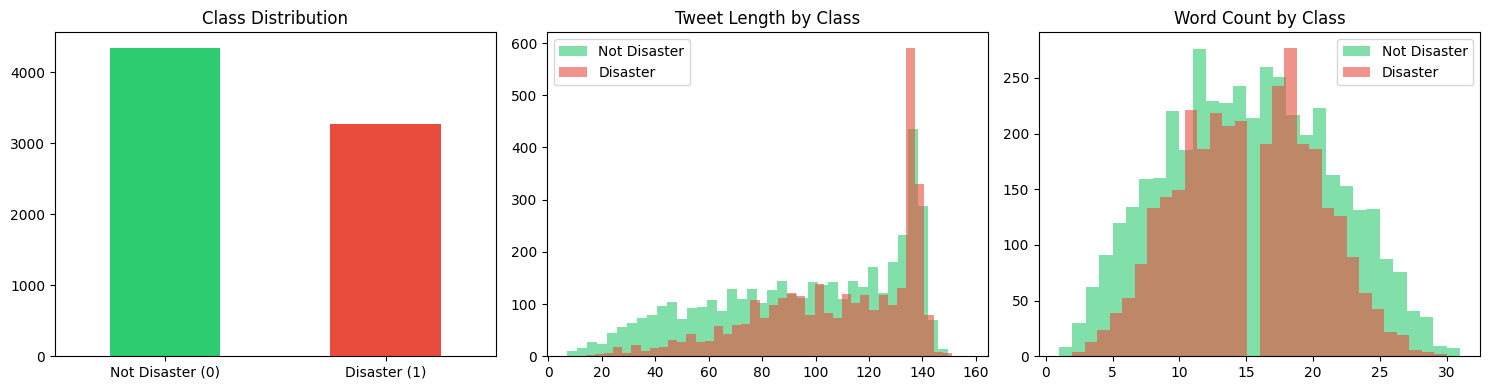


Missing values:
id               0
keyword         61
location      2533
text             0
target           0
text_len         0
word_count       0
dtype: int64


In [8]:
# Target distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
train['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Not Disaster (0)', 'Disaster (1)'], rotation=0)
axes[0].set_xlabel('')

# Tweet length distribution
train['text_len'] = train['text'].str.len()
test['text_len']  = test['text'].str.len()
axes[1].hist(train[train['target']==0]['text_len'], bins=40, alpha=0.6, color='#2ecc71', label='Not Disaster')
axes[1].hist(train[train['target']==1]['text_len'], bins=40, alpha=0.6, color='#e74c3c', label='Disaster')
axes[1].set_title('Tweet Length by Class')
axes[1].legend()

# Word count
train['word_count'] = train['text'].str.split().str.len()
axes[2].hist(train[train['target']==0]['word_count'], bins=30, alpha=0.6, color='#2ecc71', label='Not Disaster')
axes[2].hist(train[train['target']==1]['word_count'], bins=30, alpha=0.6, color='#e74c3c', label='Disaster')
axes[2].set_title('Word Count by Class')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'\nMissing values:\n{train.isnull().sum()}')

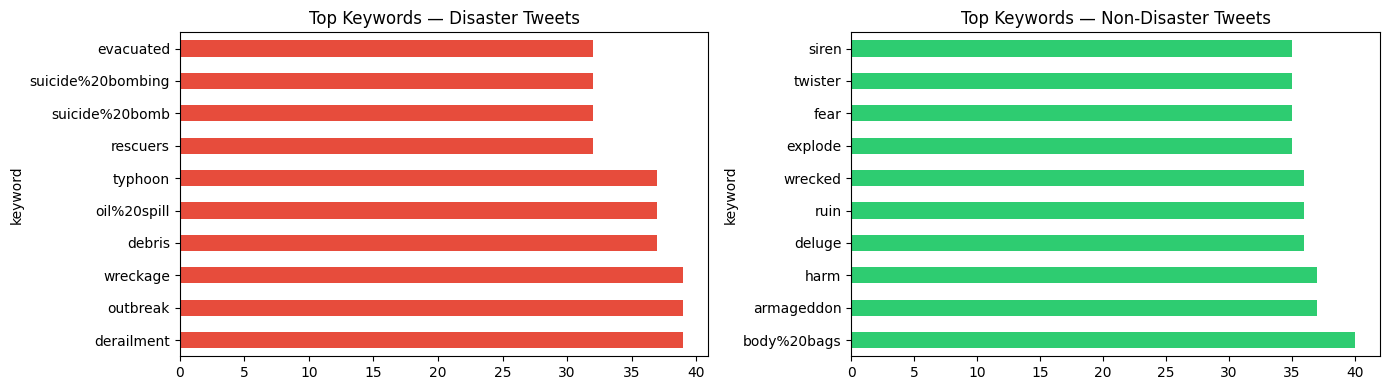

In [9]:
# Top keywords for disaster vs non-disaster
top_disaster_kw = (
    train[train['target']==1]['keyword']
    .dropna().value_counts().head(10)
)
top_nondisaster_kw = (
    train[train['target']==0]['keyword']
    .dropna().value_counts().head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
top_disaster_kw.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Top Keywords — Disaster Tweets')
top_nondisaster_kw.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Top Keywords — Non-Disaster Tweets')
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

In [10]:
def clean_text(text):
    """Clean tweet text for NLP."""
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML entities
    text = re.sub(r'&amp;|&lt;|&gt;', '', text)
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    # Keep hashtag words (remove #)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
train['clean_text'] = train['text'].apply(clean_text)
test['clean_text']  = test['text'].apply(clean_text)

# Fill missing keyword with empty string
train['keyword'] = train['keyword'].fillna('').str.replace('%20', ' ')
test['keyword']  = test['keyword'].fillna('').str.replace('%20', ' ')

# Combine keyword + clean text for richer input
train['input_text'] = train['keyword'] + ' ' + train['clean_text']
test['input_text']  = test['keyword']  + ' ' + test['clean_text']

print('Example cleaned tweet:')
print('Original :', train['text'].iloc[0])
print('Cleaned  :', train['clean_text'].iloc[0])

Example cleaned tweet:
Original : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Cleaned  : our deeds are the reason of this earthquake may allah forgive us all


## 5. Feature Engineering

In [12]:
def add_features(df):
    """Add handcrafted NLP features."""
    df = df.copy()
    df['char_count']       = df['text'].str.len()
    df['word_count']       = df['text'].str.split().str.len()
    df['unique_words']     = df['text'].apply(lambda x: len(set(str(x).lower().split())))
    df['has_url']          = df['text'].str.contains(r'http|www', regex=True).astype(int)
    df['has_hashtag']      = df['text'].str.contains('#').astype(int)
    df['hashtag_count']    = df['text'].str.count('#')
    df['has_mention']      = df['text'].str.contains('@').astype(int)
    df['exclamation_count']= df['text'].str.count('!')
    df['question_count']   = df['text'].str.count(r'\?')
    df['capital_ratio']    = df['text'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
    )
    df['has_keyword']      = (df['keyword'] != '').astype(int)
    return df

train = add_features(train)
test  = add_features(test)

META_FEATURES = ['char_count','word_count','unique_words','has_url',
                 'has_hashtag','hashtag_count','has_mention',
                 'exclamation_count','question_count','capital_ratio','has_keyword']

print('Meta features added ')
train[META_FEATURES].describe()

Meta features added 


,char_count,word_count,unique_words,has_url,has_hashtag,hashtag_count,has_mention,exclamation_count,question_count,capital_ratio,has_keyword
count,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000,7613.000000
mean,101.037436,14.903586,14.246158,0.522265,0.231315,0.446999,0.267831,0.154079,0.410613,0.099661,0.991987
std,33.781325,5.732604,5.221835,0.499537,0.421701,1.099841,0.442858,0.619387,1.833392,0.107443,0.089160
min,7.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,78.000000,11.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.038462,1.000000
50%,107.000000,15.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.074627,1.000000
75%,133.000000,19.000000,18.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.125926,1.000000
max,157.000000,31.000000,29.000000,1.000000,1.000000,13.000000,1.000000,12.000000,54.000000,1.000000,1.000000


## 6. Baseline — TF-IDF + Logistic Regression

In [18]:
from scipy.sparse import hstack
import scipy.sparse as sp
from sklearn.preprocessing import MaxAbsScaler

X = train['input_text'].values
y = train['target'].values
X_test = test['input_text'].values

# TF-IDF on words
tfidf_word = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2
)

# TF-IDF on characters
tfidf_char = TfidfVectorizer(
    max_features=20000,
    analyzer='char_wb',
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=3
)

X_word = tfidf_word.fit_transform(X)
X_char = tfidf_char.fit_transform(X)
X_meta = sp.csr_matrix(train[META_FEATURES].values.astype(float))
X_combined = hstack([X_word, X_char, X_meta])

X_test_word = tfidf_word.transform(X_test)
X_test_char = tfidf_char.transform(X_test)
X_test_meta = sp.csr_matrix(test[META_FEATURES].values.astype(float))
X_test_combined = hstack([X_test_word, X_test_char, X_test_meta])


scaler = MaxAbsScaler()  # preserves sparsity
X_combined      = scaler.fit_transform(X_combined)
X_test_combined = scaler.transform(X_test_combined)

print(f'Feature matrix shape: {X_combined.shape}')

Feature matrix shape: (7613, 43939)


In [21]:
# Switch back to lbfgs — it works great once data is scaled
lr = LogisticRegression(C=1, max_iter=3000, class_weight='balanced', solver='lbfgs')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_combined, y, cv=skf, scoring='f1', n_jobs=-1)

print(f'CV F1 scores: {cv_scores}')
print(f'Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

CV F1 scores: [0.753125   0.7484375  0.74311927 0.72217899 0.75856698]
Mean F1: 0.7451 ± 0.0125


## 7. Advanced — Multiple Models + Ensemble

In [20]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

# Models to ensemble
models = {
    'LogReg': LogisticRegression(C=5, max_iter=1000, class_weight='balanced', solver='saga', n_jobs=-1),

    'LinearSVC' : CalibratedClassifierCV(LinearSVC(C=0.5, max_iter=2000, class_weight='balanced')),
    'SGD'       : SGDClassifier(loss='modified_huber', alpha=1e-4, max_iter=200,
                                class_weight='balanced', random_state=42),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds  = np.zeros((len(train), len(models)))
test_preds = np.zeros((len(test),  len(models)))

for m_idx, (name, model) in enumerate(models.items()):
    fold_scores = []
    test_fold_preds = np.zeros(len(test))
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_combined, y)):
        X_tr, X_val = X_combined[tr_idx], X_combined[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        
        model.fit(X_tr, y_tr)
        val_pred = model.predict(X_val)
        oof_preds[val_idx, m_idx] = val_pred
        
        score = f1_score(y_val, val_pred)
        fold_scores.append(score)
        test_fold_preds += model.predict(X_test_combined) / skf.n_splits
    
    test_preds[:, m_idx] = test_fold_preds
    print(f'{name:12} | CV F1: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}')

print('\nOOF ensemble complete ✅')

LogReg       | CV F1: 0.7376 ± 0.0115
LinearSVC    | CV F1: 0.7066 ± 0.0109
SGD          | CV F1: 0.7196 ± 0.0137

OOF ensemble complete ✅


In [22]:
# Ensemble by majority vote
from scipy.stats import mode

ensemble_oof  = mode(oof_preds, axis=1)[0].ravel().astype(int)
ensemble_test = (test_preds.mean(axis=1) >= 0.5).astype(int)

ensemble_f1 = f1_score(y, ensemble_oof)
print(f'Ensemble OOF F1: {ensemble_f1:.4f}')
print(classification_report(y, ensemble_oof, target_names=['Not Disaster','Disaster']))

Ensemble OOF F1: 0.7290
              precision    recall  f1-score   support

Not Disaster       0.79      0.84      0.81      4342
    Disaster       0.76      0.70      0.73      3271

    accuracy                           0.78      7613
   macro avg       0.78      0.77      0.77      7613
weighted avg       0.78      0.78      0.78      7613



## 8. Generate Submission

In [25]:
# Use ensemble predictions
submission = pd.read_csv('/kaggle/input/competitions/nlp-getting-started/sample_submission.csv')
submission['target'] = ensemble_test
submission.to_csv('submission.csv', index=False)

print('Submission saved ')
print(f'Predicted disaster tweets: {ensemble_test.sum()} / {len(ensemble_test)}')
submission.head(10)

Submission saved 
Predicted disaster tweets: 1232 / 3263


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
5,12,1
6,21,0
7,22,0
8,27,0
9,29,0


## 10. Error Analysis
> Understanding what the model gets wrong helps you improve

In [26]:
# Fit final model on all training data
best_model = LogisticRegression(C=5, max_iter=1000, class_weight='balanced')
best_model.fit(X_combined, y)
train['pred'] = best_model.predict(X_combined)

# False Positives — model says disaster, actually not
fp = train[(train['pred']==1) & (train['target']==0)]
print('=== FALSE POSITIVES (predicted disaster, actually not) ===')
print(fp['text'].head(5).to_string())

print('\n=== FALSE NEGATIVES (missed real disasters) ===')
fn = train[(train['pred']==0) & (train['target']==1)]
print(fn['text'].head(5).to_string())

=== FALSE POSITIVES (predicted disaster, actually not) ===
248    World Annihilation vs Self Transformation http...
262    @Whippenz We need help! Horses will die!Please...
569    STAR WARS POWER OF THE JEDI COLLECTION 1 BATTL...
584    FedEx no longer to transport bioterror germs i...
591    #world FedEx no longer to transport bioterror ...

=== FALSE NEGATIVES (missed real disasters) ===
251    U.S National Park Services Tonto National Fore...
253    U.S National Park Services Tonto National Fore...
271    U.S National Park Services Tonto National Fore...
358    One Direction Is my pick for http://t.co/q2eBl...
407    Owner of Chicago-Area Gay Bar Admits to Arson ...
